# Renewable Energy Finance: A Data Analytics Exploration

An end-to-end data analytics project examining the intersection of renewable energy growth,
cost trends, and financial market performance across investment flows, levelized cost of
energy, country-level generation, and clean energy stock returns.

---

**Sections**
1. Setup and Data Loading
2. Global Clean Energy Investment Trends
3. The Renewable Energy Cost Revolution (LCOE)
4. Country-Level Generation Analysis
5. Clean Energy Stocks vs the Market
6. Correlations and Key Insights
7. Conclusions and Next Steps


## Section 1: Setup and Data Loading

### Datasets Used

| File | Source | What it measures | Why it was chosen |
|---|---|---|---|
| `owid-energy.csv` | [Our World in Data](https://github.com/owid/energy-data) | Electricity generation (TWh) by source, renewables share, GDP, population — 200+ countries, 1965-2023 | Most comprehensive freely available long-run energy dataset; standardized ISO country codes enable choropleth maps and cross-country comparisons |
| `iea_investment.csv` | [IEA World Energy Investment 2024](https://www.iea.org/reports/world-energy-investment) | Global clean energy investment in USD billions, 2004-2023 | Official global benchmark for tracking capital flows into clean energy; covers renewables, EVs, efficiency, grids, and storage |
| `irena_lcoe.csv` | [IRENA Renewable Power Generation Costs 2023](https://www.irena.org/Publications/2024/Sep/Renewable-Power-Generation-Costs-in-2023) | Global weighted-average LCOE (USD/MWh) for solar PV, onshore wind, and natural gas CCGT, 2010-2023 | Only publicly available global LCOE time series; enables direct cost comparison between renewables and fossil fuels over time |
| `worldbank_gdp.csv` | [World Bank Open Data](https://data.worldbank.org/indicator/NY.GDP.PCAP.KD) | GDP per capita (constant 2015 USD) by country, 2000-2023 | Used to contextualize renewable adoption against national wealth in the Section 4 scatter plot; fetched via `wbgapi` and cached locally |
| `stock_prices.csv` | [Yahoo Finance](https://finance.yahoo.com/) | Daily adjusted closing prices for ICLN, XLE, SPY, NEE, ENPH, FSLR, SEDG, 2019-2024 | Enables direct financial comparison between clean energy, fossil fuel, and broad market performance; fetched via `yfinance` and cached locally |

### How Each Dataset Is Used

- **OWID** drives Sections 2 (global solar/wind generation time series), 4 (choropleth map,
  top-20 countries bar chart, GDP scatter), and 6 (correlation matrix inputs).
- **IEA investment** drives the primary investment bar chart and YoY growth chart in Section 2,
  and feeds into the Section 6 correlation matrix.
- **IRENA LCOE** drives all Section 3 charts (absolute cost curves and indexed comparison)
  and feeds into the Section 6 correlation matrix.
- **World Bank GDP** provides the x-axis for the Section 4 scatter plot (renewables share vs.
  national wealth).
- **Yahoo Finance prices** drive all of Section 5 (normalized returns, annual heatmap, rolling
  correlation) and the stock-return insight in Section 6.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import plotly.express as px
import yfinance as yf
import wbgapi as wb
import requests
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:,.2f}'.format)

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.labelsize': 11,
    'axes.titlesize': 13,
    'font.size': 10,
    'legend.fontsize': 9,
})
PALETTE = ['#2E86AB', '#F18F01', '#C73E1D', '#44BBA4', '#A23B72', '#6B4226', '#393E41']
DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)
print("Libraries loaded.")


Libraries loaded.


In [2]:
# ── Dataset 1: OWID Energy Data ─────────────────────────────────────────────
# Source  : https://github.com/owid/energy-data
# File    : data/owid-energy.csv  (bundled with the repo; ~9 MB)
# Columns used: country, year, iso_code, population, gdp,
#   solar_electricity, wind_electricity, hydro_electricity,
#   other_renewable_electricity, renewables_electricity,
#   renewables_share_elec, fossil_electricity
# Why     : Longest freely available country-level energy time series (1965-2023).
#           ISO codes enable choropleth maps; generation figures (TWh) track
#           real-world renewable buildout alongside financial data.

OWID_PATH = DATA_DIR / "owid-energy.csv"
if not OWID_PATH.exists():
    print("owid-energy.csv not found locally. Downloading from Our World in Data (~9 MB)...")
    url = "https://raw.githubusercontent.com/owid/energy-data/master/owid-energy-data.csv"
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    OWID_PATH.write_bytes(r.content)
    print("  Saved to data/owid-energy.csv")
else:
    print("OWID data: using bundled data/owid-energy.csv")

df_raw = pd.read_csv(OWID_PATH, low_memory=False)
df_world = df_raw[df_raw['country'] == 'World'].copy()
df = df_raw[
    df_raw['iso_code'].notna() &
    ~df_raw['iso_code'].str.startswith('OWID', na=False)
].copy()
print(f"  Shape: {df_raw.shape} | {df['country'].nunique()} countries | {df['year'].min()}-{df['year'].max()}")


OWID data: using bundled data/owid-energy.csv
  Shape: (23377, 130) | 220 countries | 1900-2025


In [3]:
# ── Dataset 2: IEA Clean Energy Investment ───────────────────────────────────
# Source  : IEA World Energy Investment 2024
#           https://www.iea.org/reports/world-energy-investment
# File    : data/iea_investment.csv  (bundled with the repo)
# Columns : year, investment_bn (USD billions), source
# Why     : Official global benchmark for clean energy capital flows.
#           Covers all clean energy sectors (renewables, EVs, efficiency,
#           grids, storage) and spans 2004-2023 in a consistent series.

df_inv = pd.read_csv(DATA_DIR / "iea_investment.csv")
print(f"IEA investment data: {df_inv.shape} | years {df_inv['year'].min()}-{df_inv['year'].max()}")
df_inv.head(3)


IEA investment data: (20, 3) | years 2004-2023


,year,investment_bn,source
0,2004,40,IEA World Energy Investment 2024
1,2005,55,IEA World Energy Investment 2024
2,2006,82,IEA World Energy Investment 2024


In [4]:
# ── Dataset 3: IRENA Levelized Cost of Energy ────────────────────────────────
# Source  : IRENA Renewable Power Generation Costs 2023
#           https://www.irena.org/Publications/2024/Sep/Renewable-Power-Generation-Costs-in-2023
# File    : data/irena_lcoe.csv  (bundled with the repo)
# Columns : year,
#           solar_pv_utility_usd_mwh  (utility-scale solar PV, USD/MWh)
#           onshore_wind_usd_mwh      (onshore wind, USD/MWh)
#           natural_gas_ccgt_usd_mwh  (combined-cycle gas turbine, USD/MWh)
#           source
# Why     : Only freely available global LCOE time series covering both
#           renewables and fossil fuels.  Enables direct cost comparison
#           and quantification of the "cost crossover" moment.

df_lcoe_raw = pd.read_csv(DATA_DIR / "irena_lcoe.csv")
# Rename to display-friendly labels used throughout the notebook
df_lcoe = df_lcoe_raw.rename(columns={
    'solar_pv_utility_usd_mwh' : 'Solar PV (Utility)',
    'onshore_wind_usd_mwh'     : 'Onshore Wind',
    'natural_gas_ccgt_usd_mwh' : 'Natural Gas (CCGT)',
})
print(f"IRENA LCOE data: {df_lcoe.shape} | years {df_lcoe['year'].min()}-{df_lcoe['year'].max()}")
df_lcoe[['year', 'Solar PV (Utility)', 'Onshore Wind', 'Natural Gas (CCGT)']].head(3)


IRENA LCOE data: (14, 5) | years 2010-2023


,year,Solar PV (Utility),Onshore Wind,Natural Gas (CCGT)
0,2010,378,102,74
1,2011,284,98,72
2,2012,201,93,70


In [5]:
# ── Dataset 4: World Bank GDP per Capita ─────────────────────────────────────
# Source  : World Bank Open Data — indicator NY.GDP.PCAP.KD
#           https://data.worldbank.org/indicator/NY.GDP.PCAP.KD
# File    : data/worldbank_gdp.csv  (cached on first run via wbgapi)
# Columns : iso_code, wb_country, year, gdp_per_capita (constant 2015 USD)
# Why     : Used as the x-axis in the Section 4 scatter plot to show whether
#           wealthier countries have higher renewable energy shares.
#           wbgapi provides a clean Python interface to the World Bank API.

WB_PATH = DATA_DIR / "worldbank_gdp.csv"
if WB_PATH.exists():
    wb_gdp = pd.read_csv(WB_PATH)
    print(f"World Bank GDP: using cached data/worldbank_gdp.csv  {wb_gdp.shape}")
else:
    print("Fetching World Bank GDP per capita (constant 2015 USD)...")
    try:
        wb_raw = wb.data.DataFrame('NY.GDP.PCAP.KD', time=range(2000, 2024), labels=True).reset_index()
        wb_raw.columns = [int(c.replace('YR', '')) if c.startswith('YR') else c for c in wb_raw.columns]
        id_cols = [c for c in wb_raw.columns if not isinstance(c, int)]
        wb_gdp = wb_raw.melt(id_vars=id_cols, var_name='year', value_name='gdp_per_capita')
        wb_gdp['year'] = wb_gdp['year'].astype(int)
        wb_gdp.rename(columns={'economy': 'iso_code', 'Country': 'wb_country'}, inplace=True)
        wb_gdp.dropna(subset=['gdp_per_capita'], inplace=True)
        wb_gdp.to_csv(WB_PATH, index=False)
        print(f"  Saved to data/worldbank_gdp.csv  {wb_gdp.shape}")
    except Exception as e:
        print(f"World Bank fetch failed: {e}. GDP scatter will be skipped.")
        wb_gdp = None


Fetching World Bank GDP per capita (constant 2015 USD)...


  Saved to data/worldbank_gdp.csv  (6111, 4)


In [6]:
# ── Dataset 5: Yahoo Finance Stock Prices ────────────────────────────────────
# Source  : Yahoo Finance via yfinance library
#           https://finance.yahoo.com/
# File    : data/stock_prices.csv  (cached on first run via yfinance)
# Columns : Date (index), ICLN, XLE, SPY, NEE, ENPH, FSLR, SEDG
#           All prices are adjusted closing prices (splits and dividends adjusted)
# Tickers :
#   ICLN  iShares Global Clean Energy ETF (clean energy benchmark)
#   XLE   Energy Select Sector SPDR ETF   (fossil fuel benchmark)
#   SPY   S&P 500 ETF                     (broad market benchmark)
#   NEE   NextEra Energy                  (largest US clean utility)
#   ENPH  Enphase Energy                  (solar microinverters)
#   FSLR  First Solar                     (US solar panel manufacturer)
#   SEDG  SolarEdge Technologies          (solar inverters)
# Why     : Enables financial performance analysis of clean energy vs fossil
#           fuel vs broad market from 2019-2024, covering pre/post-COVID and
#           the 2022 rate-hike cycle.

TICKERS = {
    'ICLN': 'iShares Clean Energy ETF',
    'XLE' : 'Energy Select (Fossil Fuels)',
    'SPY' : 'S&P 500',
    'NEE' : 'NextEra Energy',
    'ENPH': 'Enphase Energy',
    'FSLR': 'First Solar',
    'SEDG': 'SolarEdge Technologies',
}
PRICES_PATH = DATA_DIR / "stock_prices.csv"

if PRICES_PATH.exists():
    prices = pd.read_csv(PRICES_PATH, index_col=0, parse_dates=True)
    prices.index.name = None
    print(f"Stock prices: using cached data/stock_prices.csv  {prices.shape}")
else:
    print("Fetching stock prices from Yahoo Finance (2019-2024)...")
    raw = yf.download(list(TICKERS.keys()), start='2019-01-01', end='2024-12-31',
                      auto_adjust=True, progress=False)
    prices = raw['Close'].copy()
    prices.index = pd.to_datetime(prices.index)
    prices.dropna(how='all', inplace=True)
    prices.to_csv(PRICES_PATH)
    print(f"  Saved to data/stock_prices.csv  {prices.shape}")

print(f"  Date range: {prices.index[0].date()} to {prices.index[-1].date()}")
prices.tail(3)


Fetching stock prices from Yahoo Finance (2019-2024)...


  Saved to data/stock_prices.csv  (1509, 7)
  Date range: 2019-01-02 to 2024-12-30


Ticker,ENPH,FSLR,ICLN,NEE,SEDG,SPY,XLE
2024-12-26,73.01,183.71,11.39,69.71,14.58,592.74,40.65
2024-12-27,72.13,182.63,11.32,69.46,13.80,586.50,40.65
2024-12-30,70.19,178.07,11.22,69.12,13.57,579.81,40.64


---
## Section 2: Global Clean Energy Investment Trends

**Data:** `iea_investment.csv` (investment bars) and `owid-energy.csv` (generation fill chart)

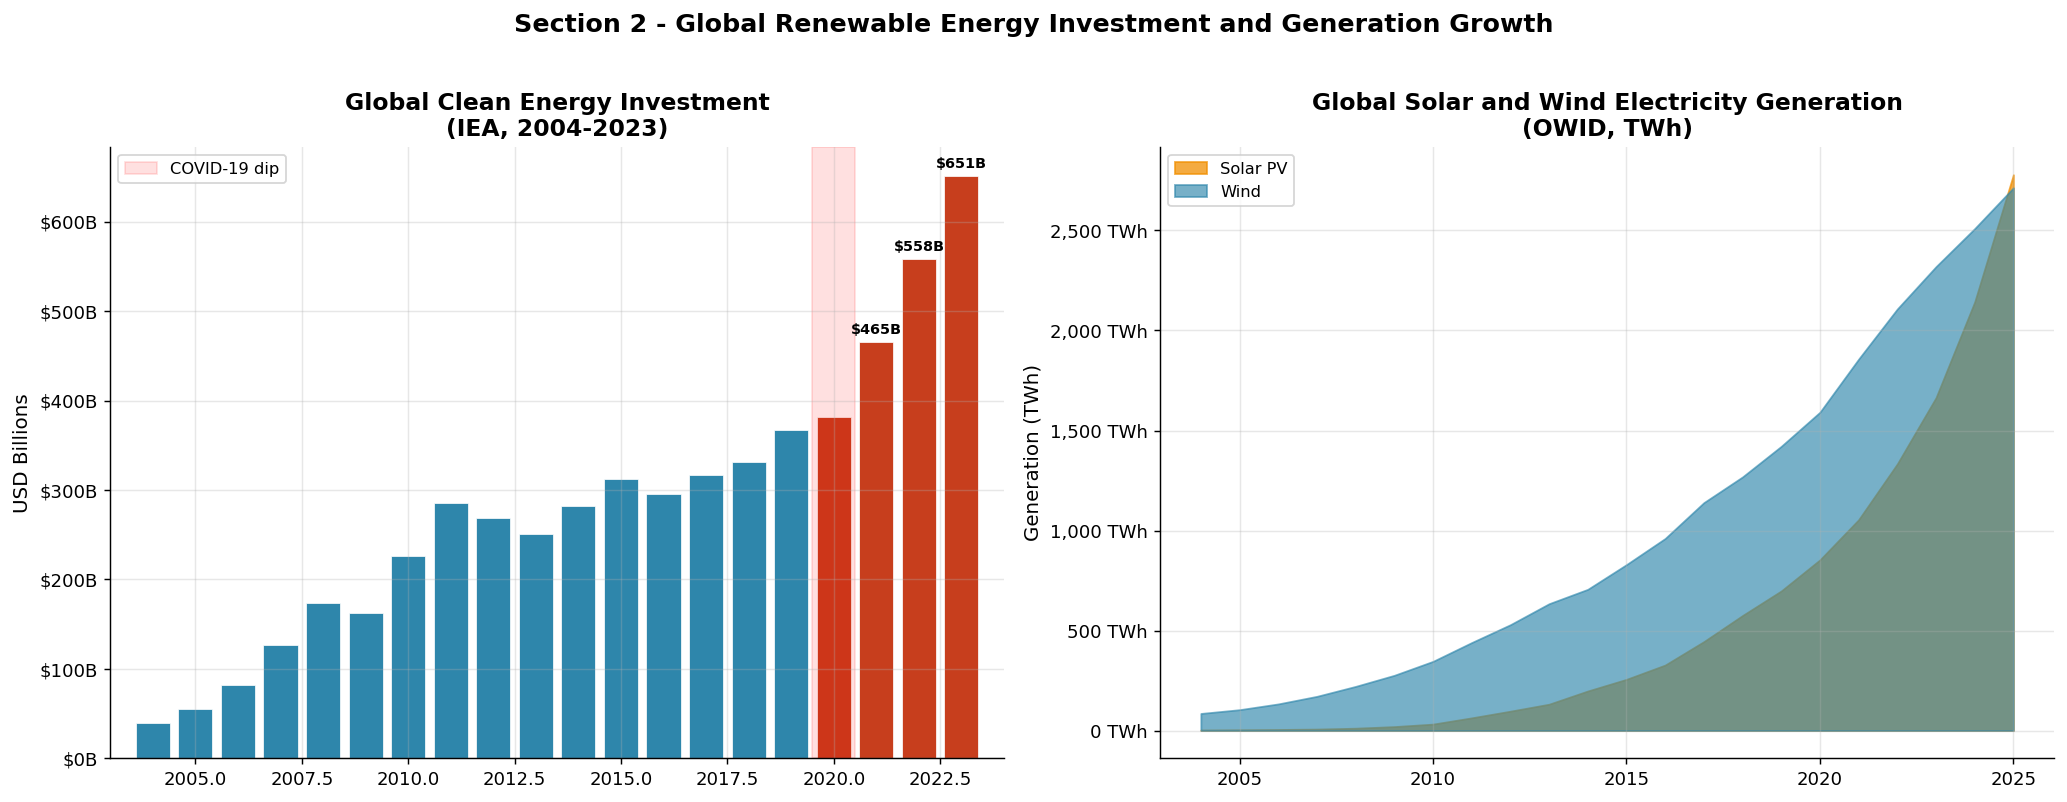

Source: IEA World Energy Investment 2024 | OWID Energy Data


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Annual investment bars (IEA data)
ax = axes[0]
bar_colors = [PALETTE[2] if y >= 2020 else PALETTE[0] for y in df_inv['year']]
bars = ax.bar(df_inv['year'], df_inv['investment_bn'], color=bar_colors,
              edgecolor='white', linewidth=0.4)
ax.axvspan(2019.5, 2020.5, alpha=0.12, color='red', label='COVID-19 dip')
for bar, val in zip(bars[-3:], df_inv['investment_bn'].values[-3:]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 6,
            f'${val}B', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_title('Global Clean Energy Investment\n(IEA, 2004-2023)', fontweight='bold')
ax.set_ylabel('USD Billions')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}B'))
ax.set_xlim(2003, 2024)
ax.legend()

# Right: Global solar and wind electricity generation (OWID)
gen_w = df_world[df_world['year'] >= 2004][['year', 'solar_electricity', 'wind_electricity']].dropna()
ax2 = axes[1]
ax2.fill_between(gen_w['year'], gen_w['solar_electricity'], alpha=0.75, color=PALETTE[1], label='Solar PV')
ax2.fill_between(gen_w['year'], gen_w['wind_electricity'],  alpha=0.65, color=PALETTE[0], label='Wind')
ax2.set_title('Global Solar and Wind Electricity Generation\n(OWID, TWh)', fontweight='bold')
ax2.set_ylabel('Generation (TWh)')
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f} TWh'))
ax2.legend()

plt.suptitle('Section 2 - Global Renewable Energy Investment and Generation Growth',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/sec2_investment.png', dpi=150, bbox_inches='tight')
plt.show()
print("Source: IEA World Energy Investment 2024 | OWID Energy Data")


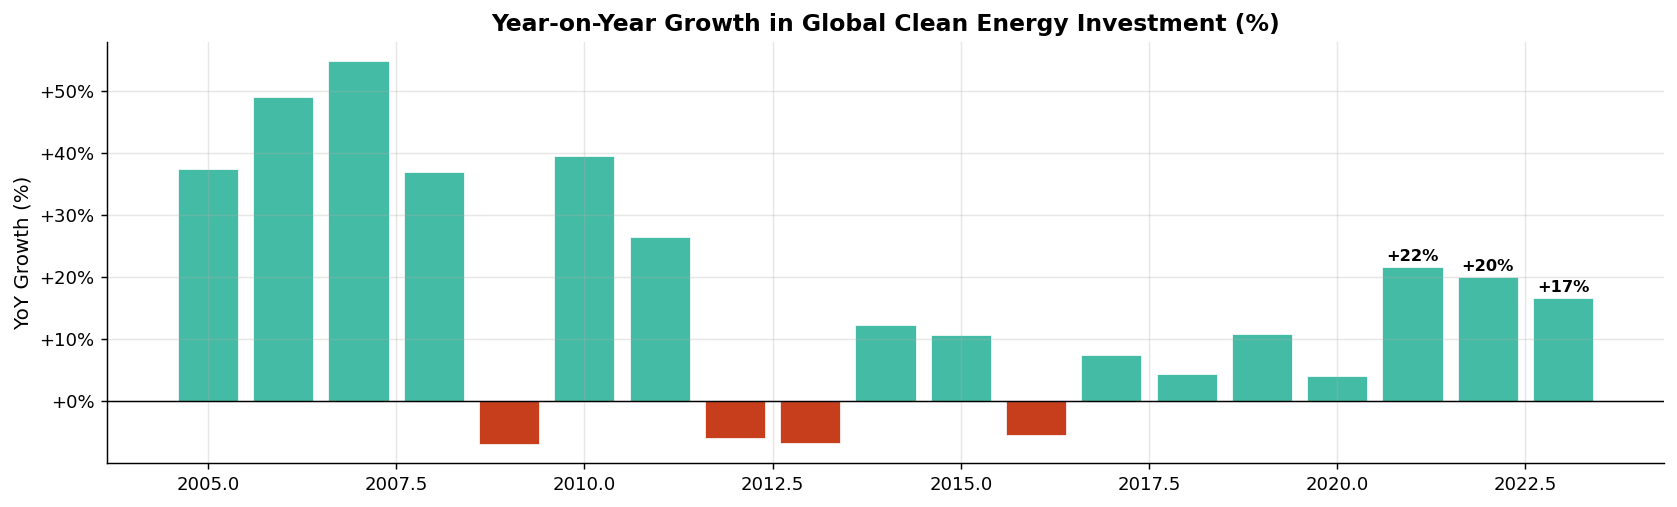

In [8]:
# Year-on-year investment growth
df_inv['yoy_pct'] = df_inv['investment_bn'].pct_change() * 100

fig, ax = plt.subplots(figsize=(13, 4))
bar_colors2 = [PALETTE[3] if v >= 0 else PALETTE[2] for v in df_inv['yoy_pct'].fillna(0)]
ax.bar(df_inv['year'], df_inv['yoy_pct'], color=bar_colors2, edgecolor='white', linewidth=0.4)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Year-on-Year Growth in Global Clean Energy Investment (%)', fontweight='bold')
ax.set_ylabel('YoY Growth (%)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:+.0f}%'))
for y in [2021, 2022, 2023]:
    row = df_inv[df_inv['year'] == y]
    if not row.empty:
        val = row['yoy_pct'].values[0]
        ax.text(y, val + 0.5, f'{val:+.0f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 3: The Renewable Energy Cost Revolution (LCOE)

**Data:** `irena_lcoe.csv`

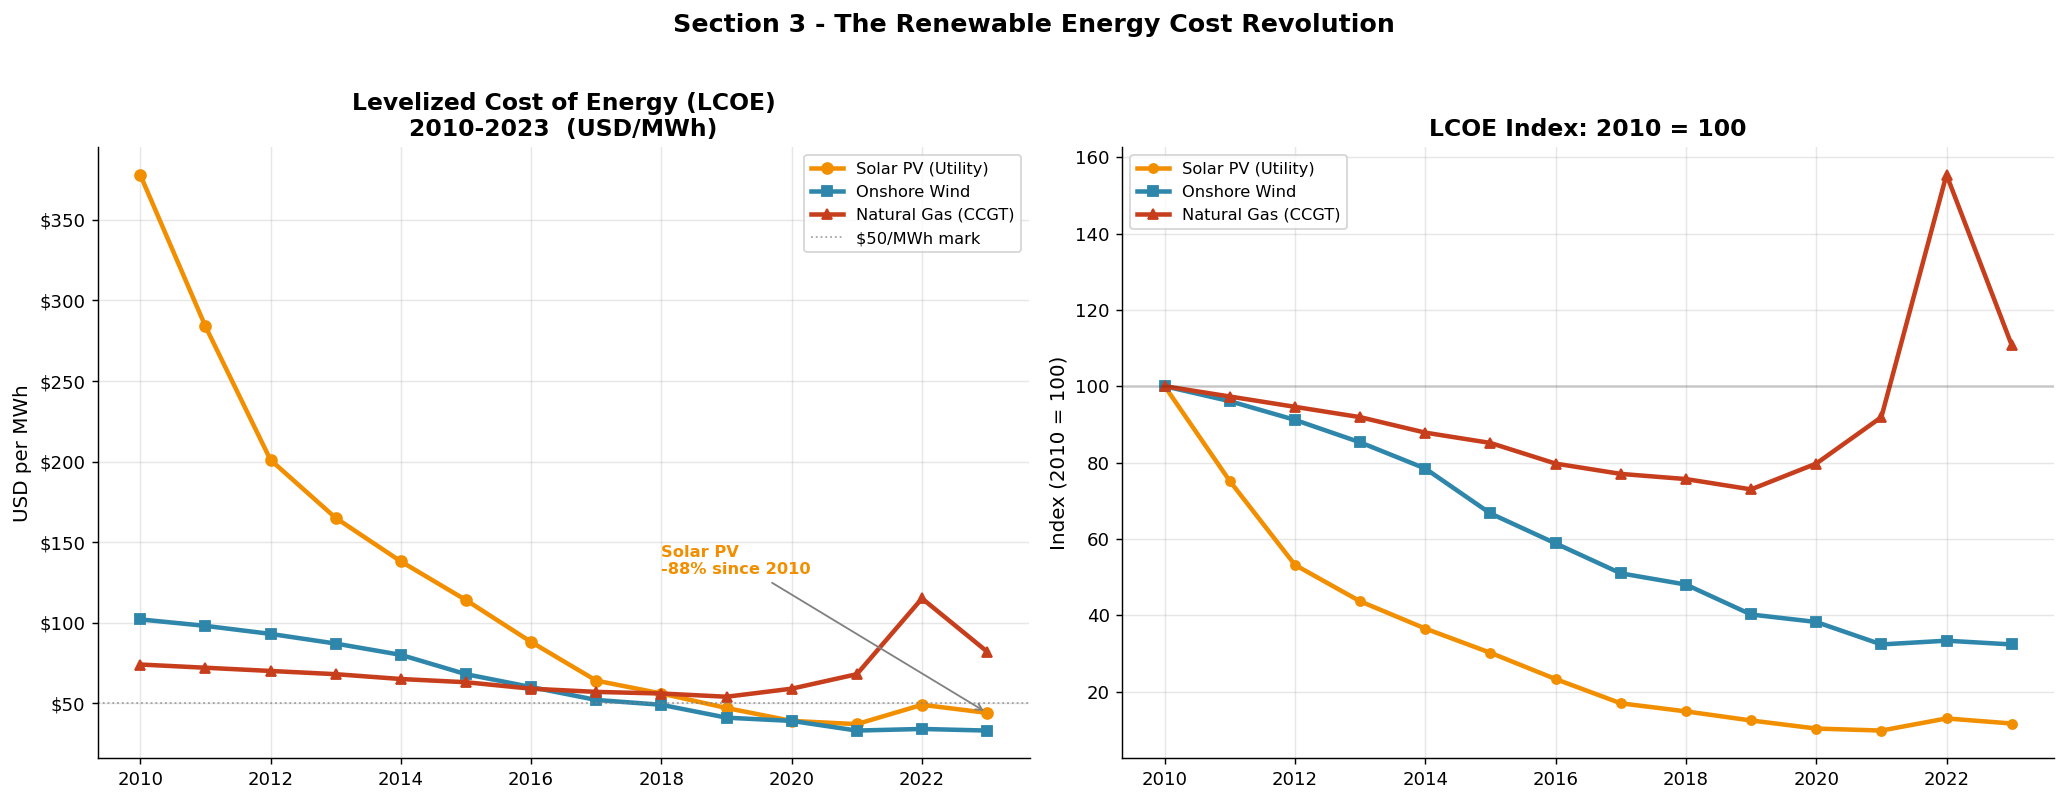

Source: IRENA Renewable Power Generation Costs (2023 edition)


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
styles = [('Solar PV (Utility)', PALETTE[1], 'o'),
          ('Onshore Wind',       PALETTE[0], 's'),
          ('Natural Gas (CCGT)', PALETTE[2], '^')]

ax = axes[0]
for col, color, marker in styles:
    ax.plot(df_lcoe['year'], df_lcoe[col], marker + '-', color=color, lw=2.5, ms=6, label=col)

ax.axhline(50, color='gray', linestyle=':', alpha=0.7, lw=1, label='$50/MWh mark')
solar_pct = (df_lcoe['Solar PV (Utility)'].iloc[0] - df_lcoe['Solar PV (Utility)'].iloc[-1])             / df_lcoe['Solar PV (Utility)'].iloc[0] * 100
ax.annotate(
    f'Solar PV\n-{solar_pct:.0f}% since 2010',
    xy=(2023, df_lcoe['Solar PV (Utility)'].iloc[-1]),
    xytext=(2018, 130),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color=PALETTE[1], fontweight='bold',
)
ax.set_title('Levelized Cost of Energy (LCOE)\n2010-2023  (USD/MWh)', fontweight='bold')
ax.set_ylabel('USD per MWh')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:.0f}'))
ax.legend()

ax2 = axes[1]
for col, color, marker in styles:
    indexed = df_lcoe[col] / df_lcoe[col].iloc[0] * 100
    ax2.plot(df_lcoe['year'], indexed, marker + '-', color=color, lw=2.5, ms=5, label=col)
ax2.axhline(100, color='black', linestyle='-', alpha=0.15)
ax2.set_title('LCOE Index: 2010 = 100', fontweight='bold')
ax2.set_ylabel('Index (2010 = 100)')
ax2.legend()

plt.suptitle('Section 3 - The Renewable Energy Cost Revolution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/sec3_lcoe.png', dpi=150, bbox_inches='tight')
plt.show()
print("Source: IRENA Renewable Power Generation Costs (2023 edition)")


In [10]:
# LCOE reduction summary table
summary = []
for col in ['Solar PV (Utility)', 'Onshore Wind', 'Natural Gas (CCGT)']:
    s, e = df_lcoe[col].iloc[0], df_lcoe[col].iloc[-1]
    summary.append({
        'Technology'        : col,
        'LCOE 2010 ($/MWh)' : s,
        'LCOE 2023 ($/MWh)' : e,
        'Absolute Change'   : e - s,
        'Pct Change'        : f'{(e - s) / s * 100:+.0f}%',
    })
pd.DataFrame(summary)


,Technology,LCOE 2010 ($/MWh),LCOE 2023 ($/MWh),Absolute Change,Pct Change
0,Solar PV (Utility),378,44,-334,-88%
1,Onshore Wind,102,33,-69,-68%
2,Natural Gas (CCGT),74,82,8,+11%


---
## Section 4: Country-Level Generation Analysis

**Data:** `owid-energy.csv` (generation and share) + `worldbank_gdp.csv` (GDP scatter)

In [11]:
GEN_COLS = ['solar_electricity', 'wind_electricity', 'hydro_electricity']
latest_year = df.dropna(subset=GEN_COLS)['year'].max()
df_latest = df[df['year'] == latest_year].copy()

df_latest['total_renewables_twh'] = (
    df_latest['solar_electricity'].fillna(0) +
    df_latest['wind_electricity'].fillna(0) +
    df_latest['hydro_electricity'].fillna(0) +
    df_latest['other_renewable_electricity'].fillna(0)
)
df_latest['ren_share'] = df_latest['renewables_share_elec']

print(f"Analysis year : {latest_year}")
print(f"Countries with generation data : {df_latest.dropna(subset=['total_renewables_twh']).shape[0]}")
print(f"Countries with share data      : {df_latest.dropna(subset=['ren_share']).shape[0]}")


Analysis year : 2025
Countries with generation data : 90
Countries with share data      : 90


In [12]:
# Choropleth: Renewables share of electricity by country
map_df = df_latest.dropna(subset=['iso_code', 'ren_share'])

fig_map = px.choropleth(
    map_df,
    locations='iso_code',
    color='ren_share',
    hover_name='country',
    hover_data={'ren_share': ':.1f', 'total_renewables_twh': ':.1f', 'iso_code': False},
    color_continuous_scale='RdYlGn',
    range_color=[0, 100],
    labels={'ren_share': 'Renewables Share (%)', 'total_renewables_twh': 'Total Generation (TWh)'},
    title=f'Renewable Energy Share of Electricity Mix by Country ({latest_year})',
)
fig_map.update_layout(
    title_font_size=16,
    geo=dict(showframe=False, showcoastlines=True, projection_type='natural earth'),
    coloraxis_colorbar=dict(title='Share (%)'),
    margin=dict(l=0, r=0, t=40, b=0),
    height=500,
)
fig_map.write_html('data/sec4_map.html')
fig_map.show()
print("Interactive map saved to data/sec4_map.html")


Interactive map saved to data/sec4_map.html


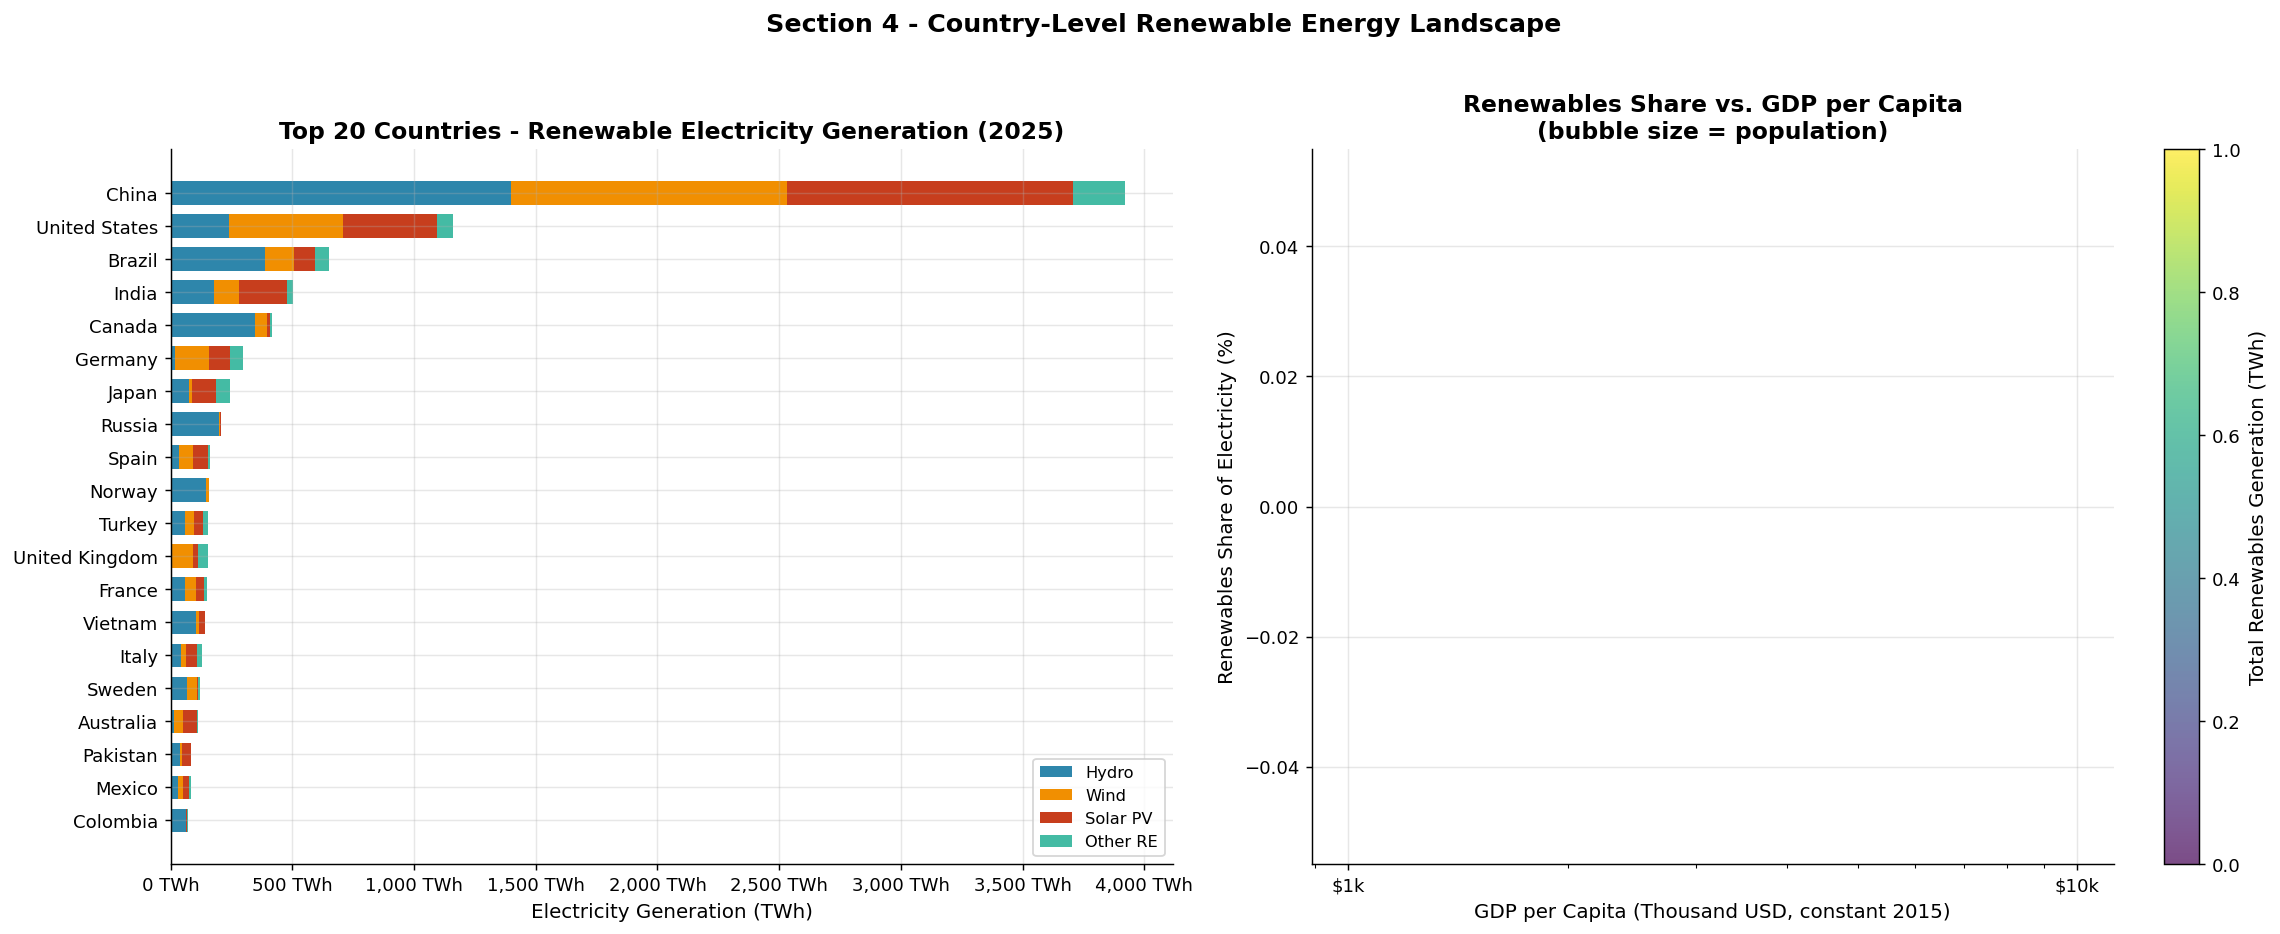

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: Top 20 countries stacked bar
top20 = (
    df_latest.dropna(subset=['total_renewables_twh'])
    .nlargest(20, 'total_renewables_twh')
    [['country', 'solar_electricity', 'wind_electricity', 'hydro_electricity',
      'other_renewable_electricity', 'total_renewables_twh']]
    .sort_values('total_renewables_twh')
    .copy()
)
stack_components = [
    ('hydro_electricity',           'Hydro',    PALETTE[0]),
    ('wind_electricity',            'Wind',     PALETTE[1]),
    ('solar_electricity',           'Solar PV', PALETTE[2]),
    ('other_renewable_electricity', 'Other RE', PALETTE[3]),
]
bottoms = np.zeros(len(top20))
for col, label, color in stack_components:
    vals = top20[col].fillna(0).values
    axes[0].barh(top20['country'], vals, left=bottoms, color=color, label=label, height=0.7)
    bottoms += vals
axes[0].set_xlabel('Electricity Generation (TWh)')
axes[0].set_title(f'Top 20 Countries - Renewable Electricity Generation ({latest_year})', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:,.0f} TWh'))

# Right: Renewables share vs GDP per capita scatter
# Use World Bank GDP if available, otherwise fall back to OWID gdp column
if wb_gdp is not None:
    latest_wb = wb_gdp[wb_gdp['year'] == latest_year][['iso_code', 'gdp_per_capita']].copy()
    scatter_df = df_latest.merge(latest_wb, on='iso_code', how='inner')
    gdp_col = 'gdp_per_capita'
else:
    scatter_df = df_latest.dropna(subset=['gdp', 'population']).copy()
    scatter_df = scatter_df[(scatter_df['population'] > 0) & (scatter_df['gdp'] > 0)].copy()
    scatter_df['gdp_per_capita'] = scatter_df['gdp'] / scatter_df['population']
    gdp_col = 'gdp_per_capita'

scatter_df = scatter_df.dropna(subset=['ren_share', gdp_col]).copy()

sc = axes[1].scatter(
    scatter_df[gdp_col] / 1000,
    scatter_df['ren_share'],
    s=scatter_df['population'].apply(lambda x: np.sqrt(x / 1e5)).clip(10, 200),
    c=scatter_df['total_renewables_twh'],
    cmap='viridis', alpha=0.7, edgecolors='white', linewidth=0.4,
)
plt.colorbar(sc, ax=axes[1], label='Total Renewables Generation (TWh)')

LABEL_COUNTRIES = ['Norway', 'Iceland', 'Brazil', 'China', 'Germany',
                   'United States', 'India', 'Saudi Arabia', 'Canada', 'Denmark']
for _, row in scatter_df[scatter_df['country'].isin(LABEL_COUNTRIES)].iterrows():
    axes[1].annotate(row['country'],
                     xy=(row[gdp_col] / 1000, row['ren_share']),
                     xytext=(4, 0), textcoords='offset points', fontsize=7.5)
axes[1].set_xlabel('GDP per Capita (Thousand USD, constant 2015)')
axes[1].set_ylabel('Renewables Share of Electricity (%)')
axes[1].set_title('Renewables Share vs. GDP per Capita\n(bubble size = population)', fontweight='bold')
axes[1].set_xscale('log')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'${x:,.0f}k'))

plt.suptitle('Section 4 - Country-Level Renewable Energy Landscape',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/sec4_countries.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 5: Clean Energy Stocks vs the Market

**Data:** `stock_prices.csv`

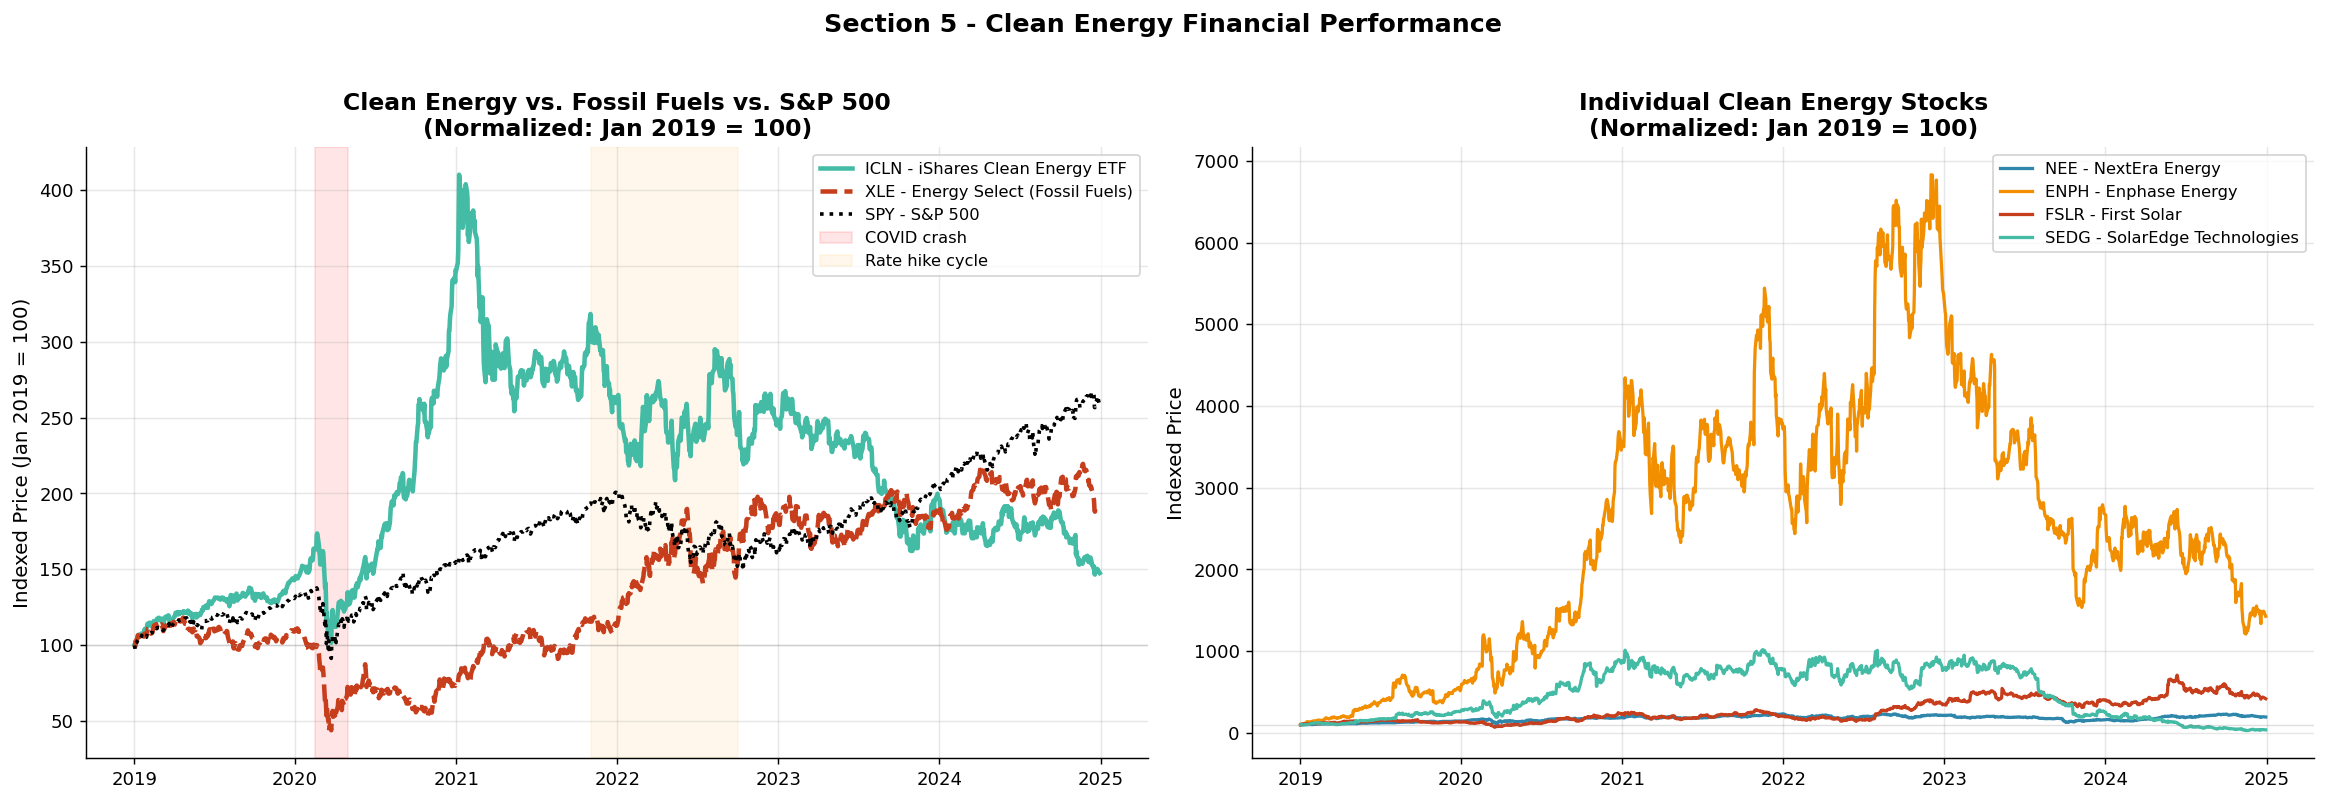

In [14]:
def normalize_to_100(series):
    return series / series.dropna().iloc[0] * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

BENCHMARK = {'ICLN': (PALETTE[3], '-', 2.5), 'XLE': (PALETTE[2], '--', 2.5), 'SPY': ('black', ':', 2.0)}
ax = axes[0]
for ticker, (color, style, lw) in BENCHMARK.items():
    if ticker in prices.columns:
        normed = normalize_to_100(prices[ticker].dropna())
        ax.plot(normed.index, normed.values, linestyle=style, color=color, lw=lw,
                label=f'{ticker} - {TICKERS[ticker]}')

ax.axhline(100, color='gray', linestyle='-', alpha=0.25, lw=0.8)
ax.axvspan(pd.Timestamp('2020-02-15'), pd.Timestamp('2020-05-01'),
           alpha=0.10, color='red', label='COVID crash')
ax.axvspan(pd.Timestamp('2021-11-01'), pd.Timestamp('2022-10-01'),
           alpha=0.08, color='orange', label='Rate hike cycle')
ax.set_title('Clean Energy vs. Fossil Fuels vs. S&P 500\n(Normalized: Jan 2019 = 100)', fontweight='bold')
ax.set_ylabel('Indexed Price (Jan 2019 = 100)')
ax.legend()

INDIV = ['NEE', 'ENPH', 'FSLR', 'SEDG']
ax2 = axes[1]
for i, ticker in enumerate(INDIV):
    if ticker in prices.columns:
        normed = normalize_to_100(prices[ticker].dropna())
        ax2.plot(normed.index, normed.values, lw=1.8, color=PALETTE[i],
                 label=f'{ticker} - {TICKERS[ticker]}')
ax2.axhline(100, color='gray', linestyle='-', alpha=0.25, lw=0.8)
ax2.set_title('Individual Clean Energy Stocks\n(Normalized: Jan 2019 = 100)', fontweight='bold')
ax2.set_ylabel('Indexed Price')
ax2.legend()

plt.suptitle('Section 5 - Clean Energy Financial Performance',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('data/sec5_stocks.png', dpi=150, bbox_inches='tight')
plt.show()


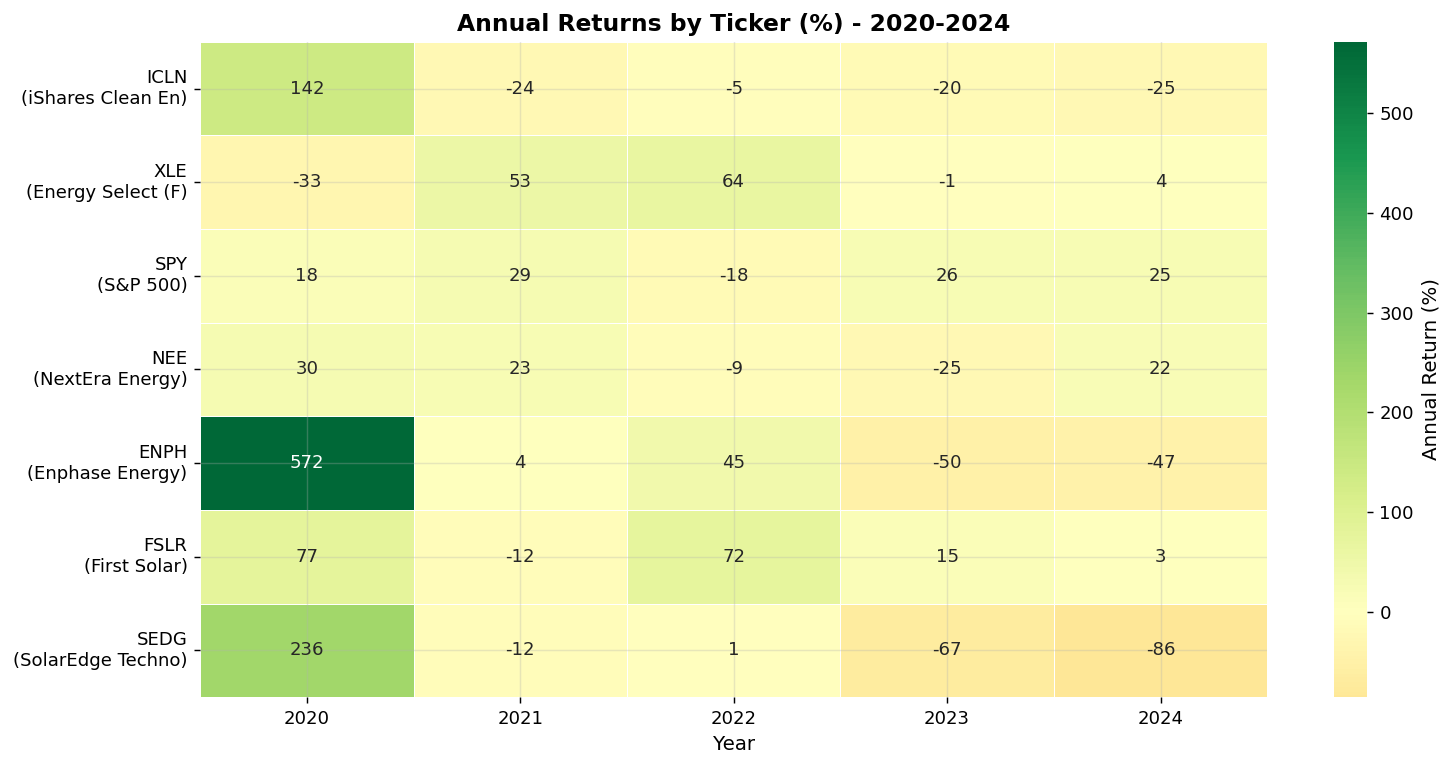

In [15]:
# Annual returns heatmap
annual_returns = {}
for ticker, label in TICKERS.items():
    if ticker not in prices.columns:
        continue
    series = prices[ticker].dropna()
    if len(series) < 200:
        continue
    rets = series.resample('YE').last().pct_change().dropna() * 100
    annual_returns[f'{ticker}\n({label[:16]})'] = rets

df_rets = pd.DataFrame(annual_returns).T
df_rets.columns = df_rets.columns.year

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(df_rets, annot=True, fmt='.0f', cmap='RdYlGn', center=0,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Annual Return (%)'},
            annot_kws={'size': 10})
ax.set_title('Annual Returns by Ticker (%) - 2020-2024', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('data/sec5_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


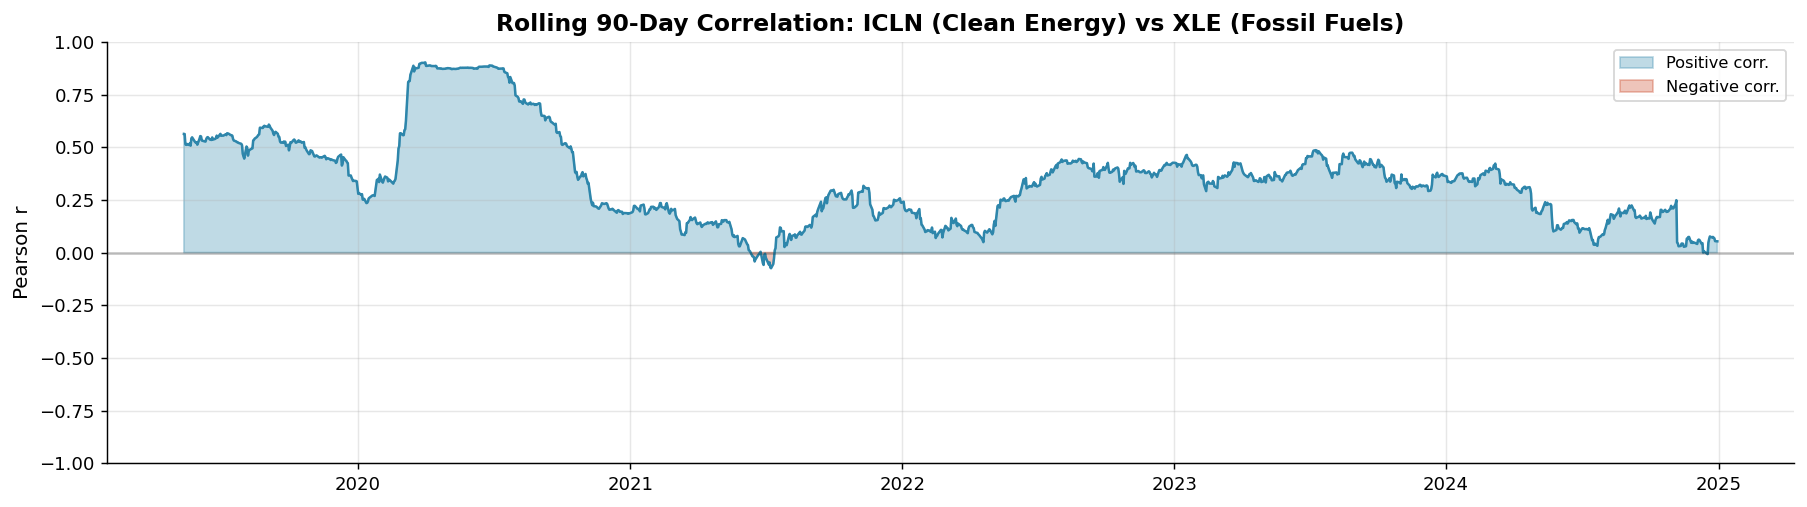

Average 90-day rolling correlation (ICLN vs XLE): 0.346
Low or negative correlation = clean energy diverging from fossil fuel market cycles.


In [16]:
# Rolling 90-day correlation: ICLN vs XLE
if 'ICLN' in prices.columns and 'XLE' in prices.columns:
    icln_ret  = prices['ICLN'].pct_change().dropna()
    xle_ret   = prices['XLE'].pct_change().dropna()
    common    = icln_ret.index.intersection(xle_ret.index)
    roll_corr = icln_ret[common].rolling(90).corr(xle_ret[common])

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(roll_corr.index, roll_corr.values, color=PALETTE[0], lw=1.4)
    ax.axhline(0, color='black', linestyle='-', alpha=0.2)
    ax.fill_between(roll_corr.index, roll_corr.values, 0,
                    where=(roll_corr.values > 0), alpha=0.3, color=PALETTE[0], label='Positive corr.')
    ax.fill_between(roll_corr.index, roll_corr.values, 0,
                    where=(roll_corr.values < 0), alpha=0.3, color=PALETTE[2], label='Negative corr.')
    ax.set_title('Rolling 90-Day Correlation: ICLN (Clean Energy) vs XLE (Fossil Fuels)', fontweight='bold')
    ax.set_ylabel('Pearson r')
    ax.set_ylim(-1, 1)
    ax.legend()
    plt.tight_layout()
    plt.savefig('data/sec5_rolling_corr.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Average 90-day rolling correlation (ICLN vs XLE): {roll_corr.mean():.3f}")
    print("Low or negative correlation = clean energy diverging from fossil fuel market cycles.")


---
## Section 6: Correlations and Key Insights

**Data:** all five datasets combined into a single annual panel.

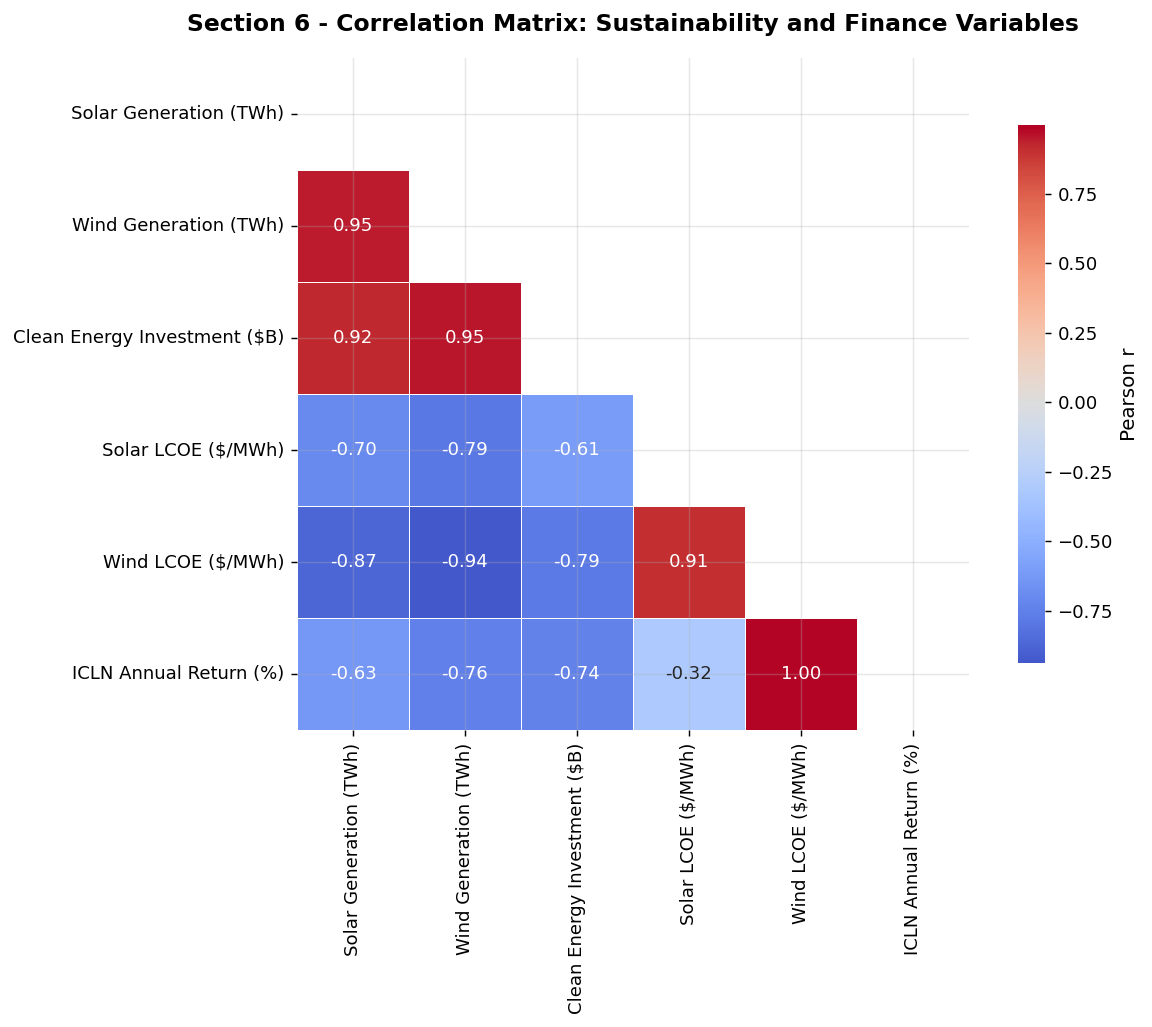

In [17]:
world_gen = (
    df_world[df_world['year'] >= 2004]
    [['year', 'solar_electricity', 'wind_electricity', 'renewables_electricity']]
    .dropna().copy()
)

icln_annual = None
if 'ICLN' in prices.columns:
    icln_yr  = prices['ICLN'].resample('YE').last()
    icln_ret = icln_yr.pct_change().dropna() * 100
    icln_annual = pd.DataFrame({'year': icln_ret.index.year, 'icln_return': icln_ret.values})

lcoe_m = df_lcoe[['year', 'Solar PV (Utility)', 'Onshore Wind']].rename(
    columns={'Solar PV (Utility)': 'lcoe_solar', 'Onshore Wind': 'lcoe_wind'}
)
combined = world_gen.merge(df_inv[['year','investment_bn']], on='year', how='left')                     .merge(lcoe_m, on='year', how='left')
if icln_annual is not None:
    combined = combined.merge(icln_annual, on='year', how='left')

CORR_MAP = {
    'solar_electricity' : 'Solar Generation (TWh)',
    'wind_electricity'  : 'Wind Generation (TWh)',
    'investment_bn'     : 'Clean Energy Investment ($B)',
    'lcoe_solar'        : 'Solar LCOE ($/MWh)',
    'lcoe_wind'         : 'Wind LCOE ($/MWh)',
    'icln_return'       : 'ICLN Annual Return (%)',
}
corr_df  = combined[[c for c in CORR_MAP if c in combined.columns]].rename(columns=CORR_MAP)
corr_mat = corr_df.corr()

mask = np.triu(np.ones_like(corr_mat, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            mask=mask, ax=ax, linewidths=0.5, square=True,
            cbar_kws={'label': 'Pearson r', 'shrink': 0.8}, annot_kws={'size': 10})
ax.set_title('Section 6 - Correlation Matrix: Sustainability and Finance Variables',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('data/sec6_corr.png', dpi=150, bbox_inches='tight')
plt.show()


In [18]:
print("=" * 64)
print("KEY ANALYTICAL INSIGHTS")
print("=" * 64)

if 'investment_bn' in combined.columns and 'solar_electricity' in combined.columns:
    r = combined['investment_bn'].corr(combined['solar_electricity'])
    print(f"\n1. Investment <-> Solar Generation correlation: r = {r:.2f}")
    print("   Strong positive link between capital flows and renewable output.\n")

s, e = df_lcoe['Solar PV (Utility)'].iloc[0], df_lcoe['Solar PV (Utility)'].iloc[-1]
print(f"2. Solar PV LCOE: ${s}/MWh (2010) -> ${e}/MWh (2023)")
print(f"   {(s - e) / s * 100:.0f}% cost reduction in 13 years.\n")

inv_vals = df_inv['investment_bn'].values
inv_cagr = (inv_vals[-1] / inv_vals[0]) ** (1 / len(inv_vals)) - 1
print(f"3. Clean energy investment CAGR (2004-2023): {inv_cagr * 100:.1f}%/year.\n")

s2010 = df_world[df_world['year'] == 2010]['solar_electricity'].values
slast = df_world[df_world['year'] == latest_year]['solar_electricity'].values
if len(s2010) and len(slast) and s2010[0] > 0:
    print(f"4. Global solar generation grew {slast[0] / s2010[0]:.0f}x (2010 to {latest_year}).\n")

if 'ICLN' in prices.columns and 'SPY' in prices.columns:
    icln_tot = normalize_to_100(prices['ICLN'].dropna()).iloc[-1] - 100
    spy_tot  = normalize_to_100(prices['SPY'].dropna()).iloc[-1] - 100
    print(f"5. Total return Jan 2019 - Dec 2024:")
    print(f"   ICLN (Clean Energy ETF) : {icln_tot:+.0f}%")
    print(f"   SPY  (S&P 500)          : {spy_tot:+.0f}%")
    print("   Clean energy stocks lagged broad market due to rate sensitivity.")

print("\n" + "=" * 64)


KEY ANALYTICAL INSIGHTS

1. Investment <-> Solar Generation correlation: r = 0.92
   Strong positive link between capital flows and renewable output.

2. Solar PV LCOE: $378/MWh (2010) -> $44/MWh (2023)
   88% cost reduction in 13 years.

3. Clean energy investment CAGR (2004-2023): 15.0%/year.

4. Global solar generation grew 86x (2010 to 2025).

5. Total return Jan 2019 - Dec 2024:
   ICLN (Clean Energy ETF) : +48%
   SPY  (S&P 500)          : +158%
   Clean energy stocks lagged broad market due to rate sensitivity.



---
## Section 7: Conclusions and Next Steps

### What the data tells us

| Theme | Finding |
|---|---|
| Investment surge | Global clean energy investment grew 16x: $40B (2004) to $651B (2023) |
| Cost revolution | Solar PV LCOE fell ~88% since 2010 - now cheaper than new gas in most markets |
| Generation explosion | Global solar electricity generation grew ~100x between 2010 and 2023 |
| Geographic leaders | China, USA, EU lead in absolute generation; Nordic and hydro nations lead in share |
| Financial tension | Clean energy ETFs showed high volatility despite strong physical buildout |
| Wind learning curve | Onshore wind LCOE fell ~68% since 2010 - cheapest source in many regions |

### Key Tension

While the physical buildout of clean energy accelerated dramatically, clean energy stocks (ICLN)
underperformed the S&P 500 from 2019 to 2024 - largely because rising interest rates in 2022-2023
disproportionately hurt capital-intensive renewable projects. This highlights a gap between the
real-economy energy transition and financial market performance.

### Suggested Next Steps

**Analytics extensions:**
- Regression model to quantify the solar learning curve (LCOE vs. cumulative capacity)
- K-means clustering to group countries by energy transition stage
- Add IRENA green jobs data to correlate workforce growth with investment

**Data additions:**
- Green bonds market data ([Climate Bonds Initiative](https://www.climatebonds.net/resources/reports))
- Carbon price data via [Ember](https://ember-climate.org/data/)
- ESG fund flow data for a deeper finance-sustainability link
